In [4]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("/home/mgiammar/git_repositories/Panther-EM/experiments/reconstruction_error/reconstruction_error_df.csv")

# Average over each group in 'num_components' column
df = df.groupby("num_components").mean().reset_index()
df

,num_components,row_index,recon_error_l2,recon_error_ncc,eff_components
0,1,1686.5,0.327988,NaN,1.0
1,2,1686.5,0.275831,NaN,3.0
2,3,1686.5,0.260262,NaN,4.0
3,5,1686.5,0.233751,NaN,8.0
4,10,1686.5,0.205566,NaN,17.0
5,18,1686.5,0.183657,NaN,32.0
6,35,1686.5,0.157996,NaN,65.0
7,68,1686.5,0.133881,NaN,129.0
8,134,1686.5,0.109043,NaN,257.0
9,264,1686.5,0.087889,NaN,512.0


In [8]:
def compute_zscore_error_intervals(
    error: float,
    corr: torch.Tensor,  # (P,)
    mu: torch.Tensor,  # (P,)
    sigma: torch.Tensor,  # (P,)
) -> torch.Tensor:  # (P, 2)
    r"""Compute worst-case intervals for z-scores for a fixed reconstruction error.

    Parameters
    ----------
    error : float
        Estimated reconstruction error.
    corr : torch.Tensor
        Per-pixel correlation values, shape ``(P,)``, estimated from low-rank SVD.
    mu : torch.Tensor
        Per-pixel mean values, shape ``(P,)``, estimated from low-rank SVD.
    sigma : torch.Tensor
        Per-pixel standard deviation values, shape ``(P,)``, estimated from low-rank
        SVD.

    Returns
    -------
    torch.Tensor
        Per-pixel error intervals, shape ``(P, 2)``, where the second axis is
        ``[lower_bound, upper_bound]``. If error is correct, then interval guaranteed to
        contain the true z-score for each pixel.
    """
    sigma_min = sigma - error
    sigma_max = torch.sqrt(sigma**2 + 2 * error**2) + error
    sigma_min = torch.clamp(sigma_min, min=1e-6)
    sigma_max = torch.clamp(sigma_max, min=1e-6)

    a_max = 2 * error / sigma_min
    b_max = error * (2 * sigma_max + error) / (sigma * (sigma_min + sigma))

    zscore = (corr - mu) / sigma
    delta_z = (a_max + b_max * torch.abs(zscore)) / (1 - b_max)

    return torch.stack([zscore - delta_z, zscore + delta_z], dim=-1)

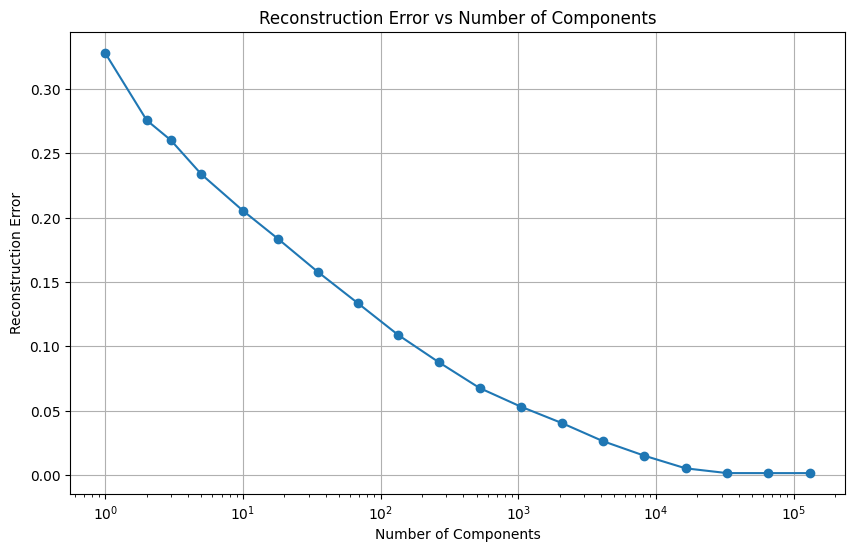

In [11]:
# Plot reconstruction error vs components
plt.figure(figsize=(10, 6))
plt.plot(df["num_components"], df["recon_error_l2"], marker="o")
plt.title("Reconstruction Error vs Number of Components")
plt.xlabel("Number of Components")
plt.ylabel("Reconstruction Error")
plt.xscale("log")
plt.grid()
plt.show()

In [12]:
low_corr = 5.5
med_corr = 8.0
hig_corr = 10.5

corr = torch.tensor([low_corr, med_corr, hig_corr])

# NOTE: Assuming perfect Gaussian background...
mu_float = 0.0
sigma_float = 1.0

mu = torch.tensor([mu_float]).broadcast_to(corr.shape)
sigma = torch.tensor([sigma_float]).broadcast_to(corr.shape)

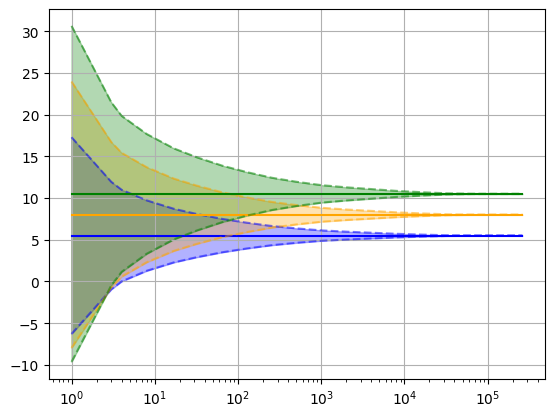

In [21]:
# Plot the reconstruction error intervals for each number of components
intervals = []
for error in df["recon_error_l2"]:
    interval = compute_zscore_error_intervals(error, corr, mu, sigma)
    intervals.append(interval)
    
intervals = torch.stack(intervals)
components = df["eff_components"].to_numpy()

for i in range(corr.shape[0]):
    color = ["blue", "orange", "green"][i]
    median = (intervals[:, i, 0] + intervals[:, i, 1]) / 2
    plt.plot(components, median.numpy(), color=color, label=f"Corr = {corr[i].item()}")
    plt.plot(components, intervals[:, i, 0].numpy(), color=color, linestyle="--", alpha=0.5)
    plt.plot(components, intervals[:, i, 1].numpy(), color=color, linestyle="--", alpha=0.5)
    plt.fill_between(
        components,
        intervals[:, i, 0].numpy(),
        intervals[:, i, 1].numpy(),
        alpha=0.3,
        color=color,
        label=f"Corr = {corr[i].item()}",
    )

plt.grid()
plt.xscale("log")
plt.show()